In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics
import warnings
warnings.filterwarnings('ignore')
import statsmodels

In [3]:
data = pd.read_csv("summary.csv")
df = data.copy()

In [39]:
# zbiór danych po usunięciu skorelowanych cech
df = df.drop(columns=['median_region1_length', 'total_contacts', 'avg_symmetry_x', 'inter_chr_ratio_x', 'total_region1_length_x', 'total_region2_length_x', 'percent_same_chr_y', 'avg_symmetry_y', 'inter_chr_ratio_y', 'std_region1_length_y', 'std_region2_length_y', 'total_region1_length_y', 'total_region2_length_y', 'top_chr1_ratio_y'])

In [5]:
file_path2 = "pred.csv"
test_df = pd.read_csv(file_path2, sep=",")
test_df.head()

,cellid,phase,order_within_phase,order
0,SCG0089_CTTATGTTCCCGCCTA-1,G1,NaN,NaN
1,SCG0093_AGAACCGCACAGCCAT-1,G1,NaN,NaN
2,SCG0090_CCAGGATGTGCTCACC-1,G2M,NaN,NaN
3,SCG0089_TACCTTTAGCACTTGG-1,G2M,NaN,NaN
4,SCG0092_TGATCAGGTTTGAGGC-1,G1,NaN,NaN


In [41]:
test_df = test_df.merge(df, on='cellid', how='left')
test_df['phase'] = test_df['phase_x']
test_df = test_df.drop(columns=['phase_x', 'phase_y'])

In [42]:
test_df.head()

,cellid,order_within_phase,order,avg_region1_length,avg_region2_length,median_region2_length,max_region1_length,max_region2_length,same_chr_contacts,percent_same_chr_x,std_region1_length_x,std_region2_length_x,top_chr1_ratio_x,avg_CDD,min_CDD,max_CDD,phase
0,SCG0089_CTTATGTTCCCGCCTA-1,NaN,NaN,77.774775,112.861712,148.0,176,188,1913,0.861712,52.247381,48.265100,0.087387,76.015773,1.0,137.0,G2M
1,SCG0093_AGAACCGCACAGCCAT-1,NaN,NaN,82.018972,110.758862,145.0,186,198,1780,0.888667,52.988611,48.531834,0.074388,75.111333,5.0,137.0,G1
2,SCG0090_CCAGGATGTGCTCACC-1,NaN,NaN,91.286683,111.855921,137.0,182,206,5479,0.807993,50.051774,44.514795,0.085976,93.186005,1.0,137.0,G2M
3,SCG0089_TACCTTTAGCACTTGG-1,NaN,NaN,79.973071,113.199759,147.0,169,203,2200,0.884244,53.567777,48.452281,0.082797,77.752714,11.0,137.0,G2M
4,SCG0092_TGATCAGGTTTGAGGC-1,NaN,NaN,79.958624,113.740778,149.0,174,167,1769,0.881854,53.243681,47.687476,0.096211,75.240639,1.0,137.0,G1


In [6]:
file_path2 = "train_data_2000.csv"
train_df = pd.read_csv(file_path2, sep=",")
train_df.head()

,cellid,phase,order_within_phase,order
0,SCG0088_CTATGAGGTACCGGAT-1,G1,0,0
1,SCG0088_GCTAAGCGTATTGGTG-1,G1,0,0
2,SCG0089_TCCATTGTCTGTAAGC-1,G1,0,0
3,SCG0092_GTTTATCTCATGCTAA-1,G1,0,0
4,SCG0092_AACCGCTCAGCTCATA-1,G1,0,0


In [44]:
train_df = train_df.merge(df, on='cellid', how='left')
train_df['phase'] = train_df['phase_x']
train_df = train_df.drop(columns=['phase_x', 'phase_y'])

In [45]:
train_df.head()

,cellid,order_within_phase,order,avg_region1_length,avg_region2_length,median_region2_length,max_region1_length,max_region2_length,same_chr_contacts,percent_same_chr_x,std_region1_length_x,std_region2_length_x,top_chr1_ratio_x,avg_CDD,min_CDD,max_CDD,phase
0,SCG0088_CTATGAGGTACCGGAT-1,0,0,90.444575,119.771226,150.0,174,186,2272,0.893082,53.884462,45.002944,0.109670,80.474843,18.0,137.0,G1
1,SCG0088_GCTAAGCGTATTGGTG-1,0,0,79.602227,114.787082,149.0,169,184,1981,0.882405,53.331965,47.639692,0.065924,76.952700,8.0,137.0,G1
2,SCG0089_TCCATTGTCTGTAAGC-1,0,0,82.597645,115.880275,148.0,180,187,1798,0.882237,54.349105,47.333828,0.080471,76.072130,11.0,137.0,G1
3,SCG0092_GTTTATCTCATGCTAA-1,0,0,84.855187,118.170269,150.0,182,187,3733,0.896494,54.501553,45.904637,0.070365,80.366082,13.0,138.0,G1
4,SCG0092_AACCGCTCAGCTCATA-1,0,0,81.523052,110.796002,147.0,183,190,2086,0.851081,53.274964,49.403040,0.081191,75.360147,1.0,137.0,G1


In [46]:
print(train_df["order"].unique())
print(test_df["order"].unique())

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 21 22 23 24
 25 26 27 28 29 30 32 33 34 35 36 37 38 39 40 41 42 43]
[nan]


In [112]:
# próba robić predykcje tylko  dla jednej fazy 
#phase = "S"
#test_df = test_df[test_df["phase"] == phase]

In [11]:
train_order = train_df.drop(columns=['cellid','phase', 'order_within_phase'])

In [113]:
train_df=train_df.drop(columns=['cellid','phase', 'order'])

In [114]:
from sklearn.model_selection import train_test_split

X = train_df.drop(columns=['order_within_phase'])
y = train_df[['order_within_phase']]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=66)

jak sie rozklada order_within_phase

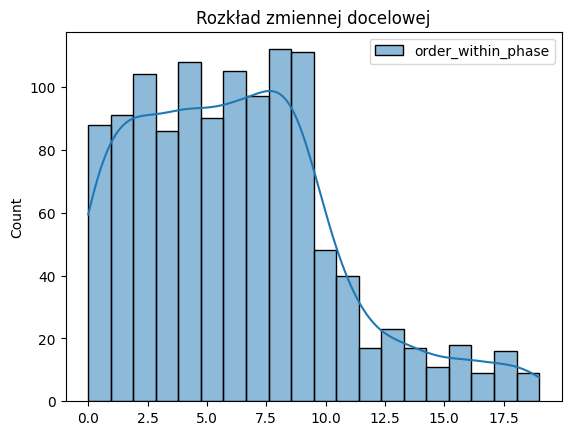

In [115]:
sns.histplot(y_train, bins=20, kde=True)
plt.title("Rozkład zmiennej docelowej")
plt.show()

rozklad wybranych cech

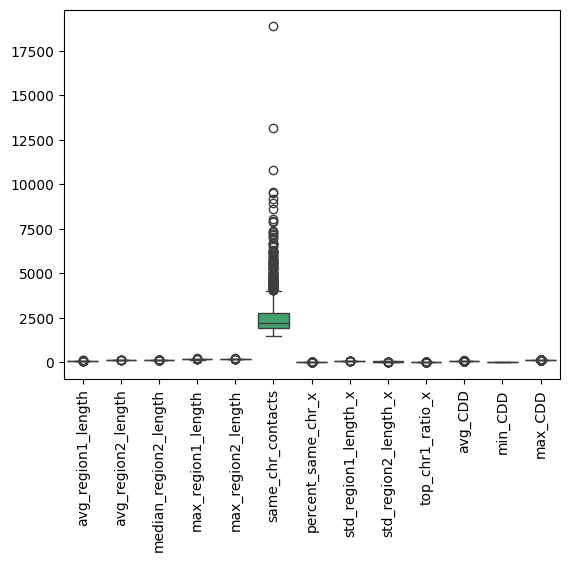

In [116]:
# Wykres pudełkowy dla każdej cechy
sns.boxplot(data=X_train)
plt.xticks(rotation=90)  # Rotacja etykiet na osi X, jeśli jest dużo cech
plt.show()

testowanie modelu MPL

In [117]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Standaryzacja
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Prosty model NN (1 ukryta warstwa, 64 neurony)
model = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=66)
model.fit(X_train_scaled, y_train)

# Ewaluacja
y_pred = model.predict(X_val_scaled)
mse = mean_squared_error(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f'MSE: {mse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R²: {r2:.4f}')

MSE: 27.9322
MAE: 4.1773
R²: -0.4860


In [118]:
# Standaryzacja
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Prosty model NN z jedną warstwą i regularyzacją
model = MLPRegressor(hidden_layer_sizes=(64,), max_iter=1000, random_state=66, alpha=0.001, learning_rate_init=0.01)
model.fit(X_train_scaled, y_train)

# Ewaluacja
y_pred = model.predict(X_val_scaled)
mse = mean_squared_error(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f'MSE: {mse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R²: {r2:.4f}')

MSE: 23.4534
MAE: 3.7984
R²: -0.2478


In [119]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_val_scaled)

print("MAE:", mean_absolute_error(y_val, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred)))
print("R²:", r2_score(y_val, y_pred))

MAE: 3.4175394593514716
RMSE: 4.386628242972769
R²: -0.023734041250673688


In [120]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 3.4979069767441855
RMSE: 4.463016016118796
R²: -0.05969863397636588


In [121]:
from sklearn.linear_model import Ridge, Lasso

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

ridge_model = Ridge(alpha=1.0)  
ridge_model.fit(X_train_scaled, y_train)

lasso_model = Lasso(alpha=0.1)  
lasso_model.fit(X_train_scaled, y_train)


y_pred_ridge = ridge_model.predict(X_val_scaled)
y_pred_lasso = lasso_model.predict(X_val_scaled)

print("Ridge:")
print("MAE:", mean_absolute_error(y_val, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_ridge)))
print("R²:", r2_score(y_val, y_pred_ridge))

print("\nLasso:")
print("MAE:", mean_absolute_error(y_val, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_lasso)))
print("R²:", r2_score(y_val, y_pred_lasso))


Ridge:
MAE: 3.4174540563694973
RMSE: 4.386559838176639
R²: -0.023702113415217996

Lasso:
MAE: 3.4219236091747662
RMSE: 4.380516823293255
R²: -0.02088351014291656


In [122]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(max_depth=5, random_state=42) 
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

print("MAE:", mean_absolute_error(y_val, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred)))
print("R²:", r2_score(y_val, y_pred))

MAE: 3.6441487866767015
RMSE: 4.605690207699767
R²: -0.12853473092511636


In [123]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

print("MAE:", mean_absolute_error(y_val, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred)))
print("R²:", r2_score(y_val, y_pred))

MAE: 3.616311550140381
RMSE: 4.582623559729246
R²: -0.11725890636444092


In [124]:
from sklearn.neighbors import KNeighborsRegressor

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
model = KNeighborsRegressor(n_neighbors=5) 
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_val_scaled)

print("MAE:", mean_absolute_error(y_val, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred)))
print("R²:", r2_score(y_val, y_pred))

MAE: 3.7049833887043184
RMSE: 4.666669830721915
R²: -0.15861630138369875


Model o r^2 dodatnim 

In [125]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

data = pd.read_csv("summary.csv")
df = data.copy()
df = df.drop(columns=[
    'median_region1_length', 'total_contacts', 'avg_symmetry_x', 'inter_chr_ratio_x',
    'total_region1_length_x', 'total_region2_length_x', 'percent_same_chr_y',
    'avg_symmetry_y', 'inter_chr_ratio_y', 'std_region1_length_y', 'std_region2_length_y',
    'total_region1_length_y', 'total_region2_length_y', 'top_chr1_ratio_y'
])

train_df = pd.read_csv("train_data_2000.csv")
train_df = train_df.merge(df, on='cellid', how='left')
train_df['phase'] = train_df['phase_x']
train_df = train_df.drop(columns=['phase_x', 'phase_y'])

train_df = train_df.drop(columns=['cellid', 'phase', 'order'])  # bo target to 'order_within_phase'

X = train_df.drop(columns=['order_within_phase'])
y = train_df['order_within_phase']

#podział i standaryzacja
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=52)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

#lepszy model MLPRegressor
model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.005,
    max_iter=1000,
    alpha=0.005,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=52
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_val_scaled)
mse = mean_squared_error(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f'MSE: {mse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R²: {r2:.4f}')

MSE: 17.4868
MAE: 3.4076
R²: 0.0590


In [126]:
train_df.head()

,order_within_phase,avg_region1_length,avg_region2_length,median_region2_length,max_region1_length,max_region2_length,same_chr_contacts,percent_same_chr_x,std_region1_length_x,std_region2_length_x,top_chr1_ratio_x,avg_CDD,min_CDD,max_CDD
0,0,90.444575,119.771226,150.0,174,186,2272,0.893082,53.884462,45.002944,0.109670,80.474843,18.0,137.0
1,0,79.602227,114.787082,149.0,169,184,1981,0.882405,53.331965,47.639692,0.065924,76.952700,8.0,137.0
2,0,82.597645,115.880275,148.0,180,187,1798,0.882237,54.349105,47.333828,0.080471,76.072130,11.0,137.0
3,0,84.855187,118.170269,150.0,182,187,3733,0.896494,54.501553,45.904637,0.070365,80.366082,13.0,138.0
4,0,81.523052,110.796002,147.0,183,190,2086,0.851081,53.274964,49.403040,0.081191,75.360147,1.0,137.0


In [127]:
test_df = test_df.drop(columns=['cellid','order','phase'])

In [128]:
test_df = test_df.drop(columns=['order_within_phase'])

In [129]:
X_test_scaled = scaler.transform(test_df)
y_test_pred = model.predict(X_test_scaled)

In [130]:
y_test_pred

array([ 5.57143513,  4.99160735, 10.83462911,  4.55616782,  5.60595816,
        9.02864781,  8.05620627,  5.91847261,  6.53411459,  5.77929241,
        6.75700467,  6.17008072, 10.51657752,  5.79708711,  5.78901258,
        8.71491714,  6.56832937,  5.81230814,  5.4458169 ,  6.99225079,
        5.38356099,  5.90541492,  5.92268316,  6.13305513,  6.73319173,
        4.77158277,  4.92592578,  6.78573144,  5.1627297 ,  5.52237119,
        5.97734715,  5.60268422,  5.72713377,  7.89244274,  6.55496039,
        5.98160297,  8.17622445,  5.35560306,  5.33502621,  6.41107967,
        7.52818218,  6.29241647,  6.62937558,  4.83524474,  5.14503954,
        7.04583089,  5.21972244,  6.6518769 ,  5.40756706,  5.89702007,
        5.25897208,  6.72643164,  6.10345124,  6.84001947,  5.27949469,
        8.53676183,  5.60382258,  6.23508199,  5.96488237,  4.79360076,
        5.30531357,  5.85998109,  5.71998914,  5.9982857 ,  6.68608084,
        5.23642423,  5.40587195,  6.73318896,  7.49851228,  5.80

In [131]:
file_path2 = "pred.csv"
test = pd.read_csv(file_path2, sep=",")

In [132]:
test['order_within_phase'] = y_test_pred.round().astype(int)

In [133]:
test.head()

,cellid,phase,order_within_phase,order
0,SCG0089_CTTATGTTCCCGCCTA-1,G2M,6,NaN
1,SCG0093_AGAACCGCACAGCCAT-1,G1,5,NaN
2,SCG0090_CCAGGATGTGCTCACC-1,G2M,11,NaN
3,SCG0089_TACCTTTAGCACTTGG-1,G2M,5,NaN
4,SCG0092_TGATCAGGTTTGAGGC-1,G1,6,NaN


In [134]:
test.to_csv("predicted2.csv", index=False)

kolumna order

In [12]:
from sklearn.model_selection import train_test_split

X_order = train_order.drop(columns=['order'])
y_order = train_order[['order']]
X_train_order, X_val_order, y_train_order, y_val_order = train_test_split(X_order, y_order, test_size=0.2, random_state=66)

In [28]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_order)
X_val_scaled = scaler.transform(X_val_order)

model = MLPRegressor(
    hidden_layer_sizes=(128,),
    activation='tanh',
    solver='adam',
    alpha=0.01,
    learning_rate='constant',
    max_iter=500,
    random_state=66
)
model.fit(X_train_scaled, y_train_order)

y_pred = model.predict(X_val_scaled)
mse = mean_squared_error(y_val_order, y_pred)
mae = mean_absolute_error(y_val_order, y_pred)
r2 = r2_score(y_val_order, y_pred)

print(f'MSE: {mse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R²: {r2:.4f}')

MSE: 131.1815
MAE: 9.1817
R²: 0.1679


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_order)
X_val_scaled = scaler.transform(X_val_order)

model = LinearRegression()
model.fit(X_train_scaled, y_train_order)
y_pred = model.predict(X_val_scaled)

print("MAE:", mean_absolute_error(y_val_order, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val_order, y_pred)))
print("R²:", r2_score(y_val_order, y_pred))

MAE: 9.773720512084209
RMSE: 11.80783951504434
R²: 0.11563358235869281


In [27]:
from sklearn.linear_model import ElasticNet     #lasso i ridge w jednym
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_order)
X_val_scaled = scaler.transform(X_val_order)

model = ElasticNet(alpha=0.1, l1_ratio=0.8, random_state=42)
model.fit(X_train_scaled, y_train_order)

y_pred = model.predict(X_val_scaled)

print("MAE:", mean_absolute_error(y_val_order, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val_order, y_pred)))
print("R²:", r2_score(y_val_order, y_pred))

MAE: 9.879937269183317
RMSE: 11.860693878213823
R²: 0.10769864411006158


In [17]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=66
)
model.fit(X_train_order, y_train_order)

y_pred = model.predict(X_val_order)

mae = mean_absolute_error(y_val_order, y_pred)
rmse = np.sqrt(mean_squared_error(y_val_order, y_pred))
r2 = r2_score(y_val_order, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 9.271580858703057
RMSE: 11.411511519011912
R²: 0.1740044552051171


In [18]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = DecisionTreeRegressor(
    max_depth=5,               
    min_samples_split=10,      
    min_samples_leaf=2,        
    max_features='sqrt',       
    random_state=42
)

model.fit(X_train_order, y_train_order)

y_pred = model.predict(X_val_order)

print("MAE:", mean_absolute_error(y_val_order, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val_order, y_pred)))
print("R²:", r2_score(y_val_order, y_pred))

MAE: 9.352509179399485
RMSE: 11.781997846503893
R²: 0.11950025011826149


In [23]:
from xgboost import XGBRegressor

model = XGBRegressor(
    colsample_bytree=0.7,
    gamma=0.5,
    learning_rate=0.01,
    max_depth=7,
    n_estimators=200,
    reg_alpha=0.1,
    reg_lambda=10,
    subsample=0.7,
    random_state=42
)
model.fit(X_train_order, y_train_order)

y_pred = model.predict(X_val_order)

print("MAE:", mean_absolute_error(y_val_order, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val_order, y_pred)))
print("R²:", r2_score(y_val_order, y_pred))

MAE: 9.2869873046875
RMSE: 11.47988326275849
R²: 0.16407692432403564


In [26]:
from sklearn.neighbors import KNeighborsRegressor

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_order)
X_val_scaled = scaler.transform(X_val_order)

model = KNeighborsRegressor(
    n_neighbors=11,
    p=1, 
    weights='uniform'
) 
model.fit(X_train_scaled, y_train_order)
y_pred = model.predict(X_val_scaled)

print("MAE:", mean_absolute_error(y_val_order, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val_order, y_pred)))
print("R²:", r2_score(y_val_order, y_pred))

MAE: 9.594986408939898
RMSE: 11.979585749353754
R²: 0.089720085673619


Najlepszy model 

In [29]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=66
)
model.fit(X_train_order, y_train_order)

y_pred = model.predict(X_val_order)

mae = mean_absolute_error(y_val_order, y_pred)
rmse = np.sqrt(mean_squared_error(y_val_order, y_pred))
r2 = r2_score(y_val_order, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 9.271580858703057
RMSE: 11.411511519011912
R²: 0.1740044552051171


In [30]:
file_path2 = "pred.csv"
test_df = pd.read_csv(file_path2, sep=",")
test_df.head()

,cellid,phase,order_within_phase,order
0,SCG0089_CTTATGTTCCCGCCTA-1,G2M,NaN,NaN
1,SCG0093_AGAACCGCACAGCCAT-1,G1,NaN,NaN
2,SCG0090_CCAGGATGTGCTCACC-1,G2M,NaN,NaN
3,SCG0089_TACCTTTAGCACTTGG-1,G2M,NaN,NaN
4,SCG0092_TGATCAGGTTTGAGGC-1,G1,NaN,NaN


In [31]:
test_df = test_df.merge(df, on='cellid', how='left')
test_df['phase'] = test_df['phase_x']
test_df = test_df.drop(columns=['phase_x', 'phase_y'])

In [32]:
test_df = test_df.drop(columns=['cellid','order','phase','order_within_phase'])

In [33]:
X_test_scaled = scaler.transform(test_df)
y_test_pred = model.predict(X_test_scaled)

In [34]:
y_test_pred

array([21.12241408, 21.12241408, 21.12241408, 21.12241408, 20.52525529,
       21.12241408, 21.12241408, 21.00138844, 21.12241408, 21.12241408,
       21.12241408, 21.12241408, 20.52525529, 21.12241408, 21.44435384,
       21.00138844, 21.12241408, 20.52525529, 20.42114346, 20.27037434,
       20.52525529, 20.52525529, 21.12241408, 21.12241408, 21.12241408,
       26.54915172, 21.12241408, 20.52525529, 20.52525529, 20.52525529,
       21.12241408, 21.12241408, 21.12241408, 21.12241408, 20.18978266,
       20.52525529, 27.60848386, 21.12241408, 20.52525529, 21.12241408,
       21.47107214, 21.12241408, 26.54915172, 20.52525529, 20.52525529,
       20.52525529, 21.12241408, 21.12241408, 20.52525529, 20.52525529,
       21.12241408, 21.12241408, 21.12241408, 21.12241408, 21.12241408,
       20.52525529, 21.12241408, 21.12241408, 21.00138844, 21.12241408,
       27.60848386, 20.27037434, 21.12241408, 21.12241408, 21.12241408,
       21.12241408, 20.52525529, 26.54915172, 21.12241408, 21.12

In [47]:
file_path2 = "predicted2.csv"
test = pd.read_csv(file_path2, sep=",")

In [48]:
test['order'] = y_test_pred.round().astype(int)

In [49]:
test.head()

,cellid,phase,order_within_phase,order
0,SCG0089_CTTATGTTCCCGCCTA-1,G2M,6,21
1,SCG0093_AGAACCGCACAGCCAT-1,G1,5,21
2,SCG0090_CCAGGATGTGCTCACC-1,G2M,11,21
3,SCG0089_TACCTTTAGCACTTGG-1,G2M,5,21
4,SCG0092_TGATCAGGTTTGAGGC-1,G1,6,21


In [50]:
test.to_csv("predicted3.csv", index=False)

In [51]:
print(test["order"].unique())

[21 20 27 28 22 25]


Order - proba PCA

In [8]:
data = pd.read_csv("summary.csv")
df = data.copy()

test_df = test_df.merge(df, on='cellid', how='left')
test_df['phase'] = test_df['phase_x']
test_df = test_df.drop(columns=['phase_x', 'phase_y'])

train_df = train_df.merge(df, on='cellid', how='left')
train_df['phase'] = train_df['phase_x']
train_df = train_df.drop(columns=['phase_x', 'phase_y'])

train_order = train_df.drop(columns=['cellid','phase'])
train_df=train_df.drop(columns=['cellid','phase', 'order'])

In [9]:
from sklearn.model_selection import train_test_split

X_order = train_order.drop(columns=['order'])
y_order = train_order[['order']]
X_train_order, X_val_order, y_train_order, y_val_order = train_test_split(X_order, y_order, test_size=0.2, random_state=66)

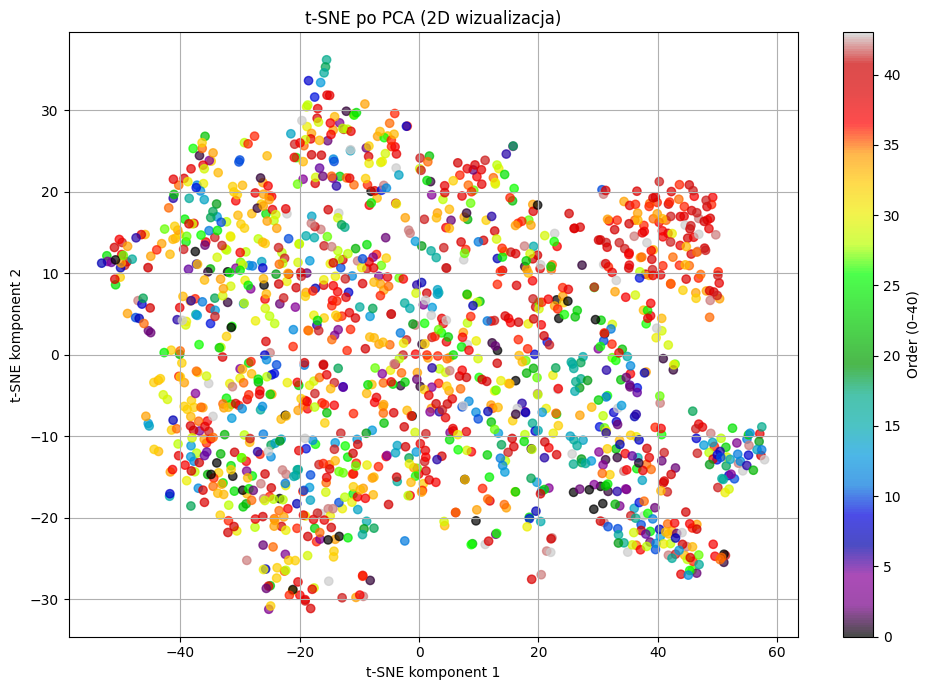

In [26]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Połącz dane treningowe i walidacyjne do wspólnej wizualizacji
X_all_scaled = np.vstack([X_train_scaled, X_val_scaled])
y_all = np.concatenate([y_train_order.values.ravel(), y_val_order.values.ravel()])

# 1. PCA do 20 komponentów
pca_20 = PCA(n_components=20)
X_pca_20 = pca_20.fit_transform(X_all_scaled)

# 3. Wykres t-SNE
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_all, cmap='nipy_spectral', alpha=0.7)
plt.colorbar(scatter, label='Order (0–40)')
plt.title('t-SNE po PCA (2D wizualizacja)')
plt.xlabel('t-SNE komponent 1')
plt.ylabel('t-SNE komponent 2')
plt.grid(True)
plt.tight_layout()
plt.show()


In [32]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Redukcja do 20 wymiarów PCA (możesz też użyć n_components=0.95)
pca = PCA(n_components=40)
X_all_pca = pca.fit_transform(X_all_scaled)

# Rozdziel z powrotem na train i val
X_train_pca = X_all_pca[:len(X_train_scaled)]
X_val_pca = X_all_pca[len(X_train_scaled):]

# Trenuj model
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_pca, y_train_order.values.ravel())

# Ewaluacja
y_pred = clf.predict(X_val_pca)
print(classification_report(y_val_order, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00         7
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         7
           7       0.00      0.00      0.00         4
           8       0.00      0.00      0.00         4
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00         7
          11       0.00      0.00      0.00         5
          12       0.00      0.00      0.00         5
          13       0.20      0.33      0.25         3
          14       0.00      0.00      0.00         5
          15       0.00      0.00      0.00         3
          16       0.44      0.80      0.57         5
          17       0.00      0.00      0.00         2
          18       0.40    

In [29]:
print("Unikalne klasy w y_train:", np.unique(y_train_order))
print("Unikalne klasy w y_val:", np.unique(y_val_order))

Unikalne klasy w y_train: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 21 22 23 24
 25 26 27 28 29 30 32 33 34 35 36 37 38 39 40 41 42 43]
Unikalne klasy w y_val: [ 0  1  2  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 21 22 23 24 25
 26 27 28 29 30 32 33 34 35 36 37 38 39 40 41 42 43]


In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=66
)
model.fit(X_train_pca, y_train_order.values.ravel()) 

# 4. Predykcja i ewaluacja
y_pred = model.predict(X_val_pca)

mae = mean_absolute_error(y_val_order, y_pred)
rmse = np.sqrt(mean_squared_error(y_val_order, y_pred))
r2 = r2_score(y_val_order, y_pred)

print("MAE (PCA):", mae)
print("RMSE (PCA):", rmse)
print("R² (PCA):", r2)

MAE (PCA): 8.975611123064875
RMSE (PCA): 11.125818117400215
R² (PCA): 0.21484523500303898


In [33]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_train = y_train_order.values.ravel()
y_val = y_val_order.values.ravel()

hgb_model = HistGradientBoostingRegressor(random_state=42)
hgb_model.fit(X_train_pca, y_train)
y_pred_hgb = hgb_model.predict(X_val_pca)

print("=== HistGradientBoostingRegressor ===")
print("MSE:", mean_squared_error(y_val, y_pred_hgb))
print("MAE:", mean_absolute_error(y_val, y_pred_hgb))
print("R^2:", r2_score(y_val, y_pred_hgb))
print()

mlp_model = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
mlp_model.fit(X_train_pca, y_train)
y_pred_mlp = mlp_model.predict(X_val_pca)

print("=== MLPRegressor ===")
print("MSE:", mean_squared_error(y_val, y_pred_mlp))
print("MAE:", mean_absolute_error(y_val, y_pred_mlp))
print("R^2:", r2_score(y_val, y_pred_mlp))

=== HistGradientBoostingRegressor ===
MSE: 129.89076059262305
MAE: 8.630130802169766
R^2: 0.17610926554532724

=== MLPRegressor ===
MSE: 240.9956007907973
MAE: 11.925642643667963
R^2: -0.5286232956830623


In [34]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Zakoduj etykiety do klasyfikacji, jeśli jeszcze nie były zakodowane
le = LabelEncoder()
le.fit(np.concatenate([y_train_order.values.ravel(), y_val_order.values.ravel()]))

y_train_cls = le.transform(y_train_order.values.ravel())
y_val_cls = le.transform(y_val_order.values.ravel())

# 1. HistGradientBoostingClassifier
hgb_clf = HistGradientBoostingClassifier(random_state=42)
hgb_clf.fit(X_train_pca, y_train_cls)
y_pred_hgb = hgb_clf.predict(X_val_pca)

print("=== HistGradientBoostingClassifier ===")
print("Accuracy:", accuracy_score(y_val_cls, y_pred_hgb))
print(classification_report(y_val_cls, y_pred_hgb))
print()

# 2. MLPClassifier
mlp_clf = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
mlp_clf.fit(X_train_pca, y_train_cls)
y_pred_mlp = mlp_clf.predict(X_val_pca)

print("=== MLPClassifier ===")
print("Accuracy:", accuracy_score(y_val_cls, y_pred_mlp))
print(classification_report(y_val_cls, y_pred_mlp))

=== HistGradientBoostingClassifier ===
Accuracy: 0.1362126245847176
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00         0
           4       0.25      0.33      0.29         3
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         7
           7       0.00      0.00      0.00         4
           8       0.00      0.00      0.00         4
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00         7
          11       0.00      0.00      0.00         5
          12       0.00      0.00      0.00         5
          13       0.00      0.00      0.00         3
          14       0.17      0.20      0.18         5
          15       0.00      0.00      0.00         3
          16 

In [35]:
# Dodanie kolumny z grupą fazy cyklu komórkowego
def assign_phase(order):
    if 0 <= order <= 19:
        return 'G1'
    elif 20 <= order <= 31:
        return 'S'
    else:
        return 'G2M'

train_order['phase'] = train_order['order'].apply(assign_phase)

In [36]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Podział cech i nowego targetu
X_order = train_order.drop(columns=['order', 'phase'])
y_phase = train_order['phase']

# Train/val split
X_train_order, X_val_order, y_train_phase, y_val_phase = train_test_split(
    X_order, y_phase, test_size=0.2, random_state=66
)

# Standaryzacja
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_order)
X_val_scaled = scaler.transform(X_val_order)

# Połączenie i PCA
X_all_scaled = np.vstack([X_train_scaled, X_val_scaled])
pca = PCA(n_components=20)
X_all_pca = pca.fit_transform(X_all_scaled)

# Rozdzielenie z powrotem
X_train_pca = X_all_pca[:len(X_train_scaled)]
X_val_pca = X_all_pca[len(X_train_scaled):]

In [37]:
# Zakodowanie etykiet faz (G1, S, G2M) jako liczby
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_phase)
y_val_encoded = le.transform(y_val_phase)

In [38]:
# Model regresyjny
reg = RandomForestRegressor(random_state=42)
reg.fit(X_train_pca, y_train_encoded)

# Predykcja i zaokrąglenie do najbliższej klasy
y_pred_encoded = reg.predict(X_val_pca)
y_pred_rounded = np.round(y_pred_encoded).astype(int)
y_pred_phase = le.inverse_transform(np.clip(y_pred_rounded, 0, len(le.classes_)-1))

# Metryki
print("=== RandomForestRegressor predicting PHASE (as numbers) ===")
print("MSE:", mean_squared_error(y_val_encoded, y_pred_encoded))
print("MAE:", mean_absolute_error(y_val_encoded, y_pred_encoded))
print("R^2:", r2_score(y_val_encoded, y_pred_encoded))

# Faza jako klasy
from sklearn.metrics import classification_report
print("\n=== Classification Report (via regression output) ===")
print(classification_report(y_val_phase, y_pred_phase))


=== RandomForestRegressor predicting PHASE (as numbers) ===
MSE: 0.3737079734219269
MAE: 0.44136212624584714
R^2: 0.15900854197714842

=== Classification Report (via regression output) ===
              precision    recall  f1-score   support

          G1       0.89      0.31      0.46        81
         G2M       0.59      0.98      0.74       165
           S       0.50      0.02      0.04        55

    accuracy                           0.62       301
   macro avg       0.66      0.43      0.41       301
weighted avg       0.66      0.62      0.53       301



=== Classification Report ===
              precision    recall  f1-score   support

          G1       0.66      0.46      0.54        81
         G2M       0.64      0.92      0.76       165
           S       0.38      0.05      0.10        55

    accuracy                           0.64       301
   macro avg       0.56      0.48      0.46       301
weighted avg       0.60      0.64      0.58       301



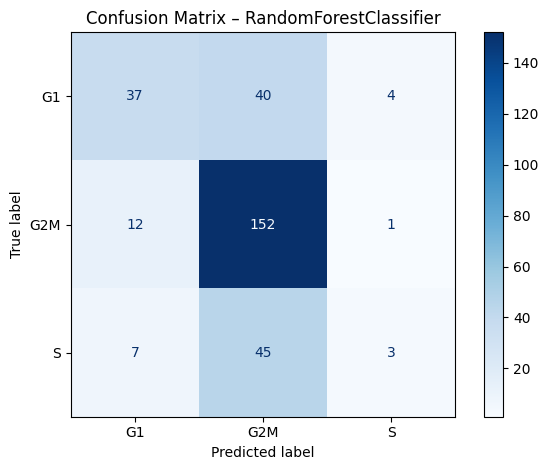

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Trening klasyfikatora
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_pca, y_train_encoded)

# Predykcja
y_pred_encoded = clf.predict(X_val_pca)
y_pred_phase = le.inverse_transform(y_pred_encoded)

# Raport
print("=== Classification Report ===")
print(classification_report(y_val_phase, y_pred_phase))

# Macierz pomyłek
cm = confusion_matrix(y_val_phase, y_pred_phase, labels=le.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix – RandomForestClassifier")
plt.grid(False)
plt.tight_layout()
plt.show()